In [11]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from energy import (
    COLOR_SERIES,
    FONTSIZE_LABEL,
    FONTSIZE_LEGEND,
    FONTSIZE_TICK,
    FONTSIZE_TITLE,
    GRID_ALPHA,
    LINEWIDTH,
    TEMPERATURE_U,
    new_figure,
)
from various import get_pair_distances, read_atoms_from_output_dumps


def finish_plot(x_label, y_label, title, legend=True, legend_loc=None):
    plt.xlabel(x_label, fontsize=FONTSIZE_LABEL)
    plt.ylabel(y_label, fontsize=FONTSIZE_LABEL)
    plt.title(title, fontsize=FONTSIZE_TITLE)
    plt.grid(True, alpha=GRID_ALPHA)
    plt.tick_params(axis="both", labelsize=FONTSIZE_TICK)
    ax = plt.gca()
    ax.xaxis.get_offset_text().set_fontsize(FONTSIZE_LABEL)
    ax.yaxis.get_offset_text().set_fontsize(FONTSIZE_LABEL)
    if legend:
        legend_kwargs = {"fontsize": FONTSIZE_LEGEND}
        if legend_loc is not None:
            legend_kwargs["loc"] = legend_loc
        plt.legend(**legend_kwargs)
    plt.tight_layout()
    plt.show()
    plt.close()


def mean_temperature_in_window(energy_data, iteration, start_offset, end_offset):
    lo = iteration + start_offset
    hi = iteration + end_offset
    mask = (energy_data["iteration"] >= lo) & (energy_data["iteration"] <= hi)
    temps = energy_data.loc[mask, "temperature"] * TEMPERATURE_U
    if temps.empty:
        raise ValueError(f"Brak próbek temperatury w iteracjach [{lo}, {hi}]")
    return float(temps.mean()), int(temps.size), lo, hi

pairs = [
    (690, 81),
    (592, 495),
    (474, 559),
    (329, 806),
    (111, 317),
    (241, 182),
    (526, 69),
    (526, 434),
    (628, 903),
    (628, 703),
    (628, 519),
]

pairs = [
    (690, 81),
    (592, 495),
    (474, 559),
    (329, 806),
    (111, 317),
    (241, 182),
    (628, 519),
]

pairs = [
    (690, 81),
    (592, 495),
    (474, 559),
    (329, 806),
    (111, 317),
    (241, 182),
    (628, 519),
    (29, 701),
    (29, 945),
]

In [2]:
exp_path = Path("/mnt/7E442D59442D1585/md/paper/exp/melting/v3")
laamps_path = exp_path / "laamps"
window = 2000

pairs = [
    (690, 81),
    (592, 495),
    (474, 559),
    (111, 317),
    (241, 182),
    (628, 519),
]

parameters_path = exp_path / "parameters.json"
if parameters_path.exists():
    with open(parameters_path, encoding="utf-8") as f:
        time_step = float(json.load(f)["time_step"])
else:
    time_step = 1e-15

In [3]:
atom_ids = sorted({atom_id for pair in pairs for atom_id in pair})
atom_data = read_atoms_from_output_dumps(laamps_path, atom_ids)
distances = get_pair_distances(atom_data, pairs)
time_elapsed = distances.index.to_series() * time_step
distances

,690-81,592-495,474-559,111-317,241-182,628-519
iteration,,,,,,
0,1.969407,1.958403,2.693082,3.778527,1.901359,4.917485
1,1.974513,1.955793,2.701249,3.761778,1.890041,4.904805
2,1.979629,1.952698,2.709522,3.745632,1.879247,4.893097
3,1.984756,1.949233,2.717893,3.730155,1.869038,4.882449
4,1.989895,1.945561,2.726357,3.715407,1.859470,4.872941
...,...,...,...,...,...,...
249996,3.347316,1.908842,9.125832,5.826953,8.261450,5.570052
249997,3.358874,1.896242,9.128578,5.825376,8.245425,5.562823
249998,3.369890,1.883401,9.130990,5.823844,8.228672,5.555986


In [19]:
distances.drop("29-701", axis=1, errors="ignore", inplace=True)
distances.drop("29-945", axis=1, errors="ignore", inplace=True)
distances.drop("329-806", axis=1, errors="ignore", inplace=True)

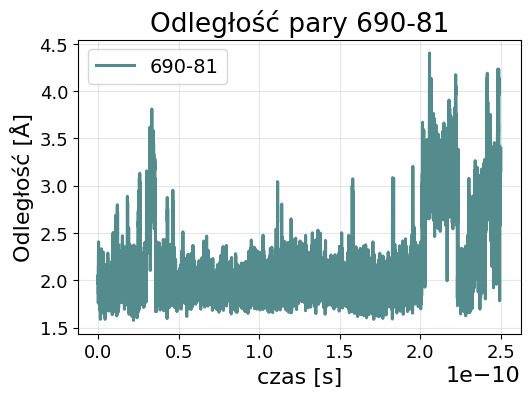

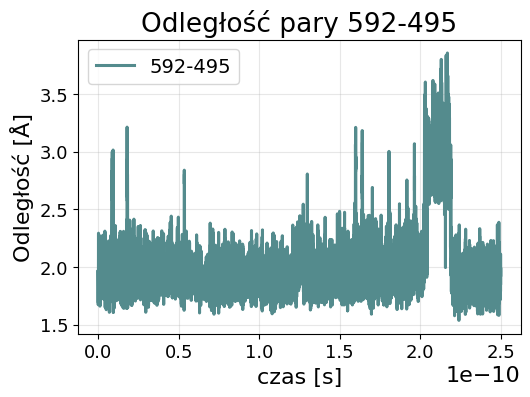

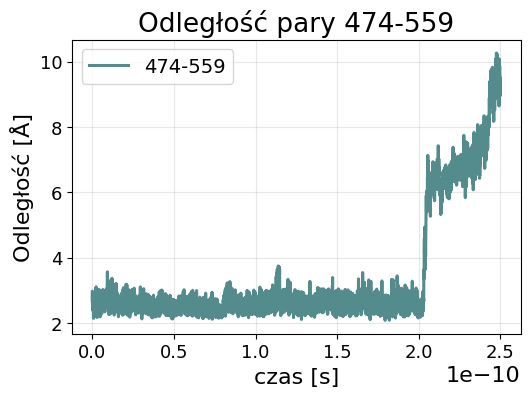

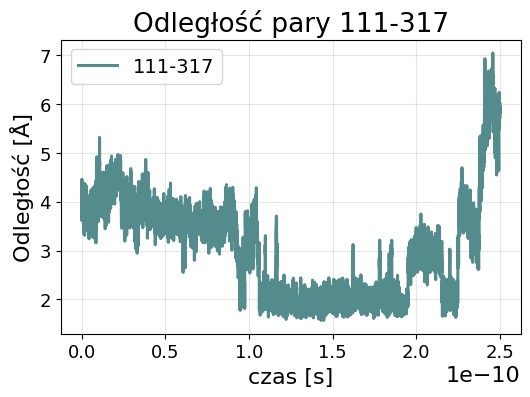

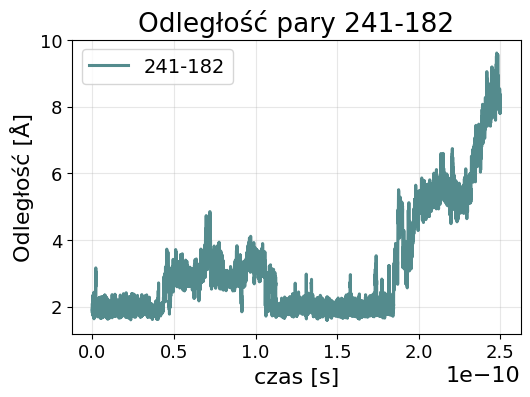

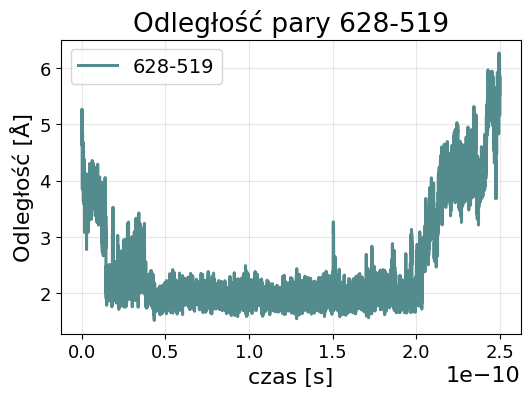

In [20]:
for column in distances.columns:
    new_figure()
    plt.plot(time_elapsed, distances[column], color=COLOR_SERIES, label=column)
    finish_plot("czas [s]", r"Odległość [Å]", f"Odległość pary {column}")

In [21]:
energy_data = pd.read_csv(exp_path / "energy.csv", header=0)
energy_data = energy_data[energy_data["iteration"] >= 1].reset_index(drop=True)

roll = distances.rolling(window=window)
rolling_std = roll.std()
rolling_mean = roll.mean()
delta = rolling_std / rolling_mean
mean_delta = delta.mean(axis=1)
mean_delta_derivative = pd.Series(
    np.gradient(mean_delta.to_numpy(), time_elapsed.to_numpy()),
    index=mean_delta.index,
)

iteration_max_delta = int(mean_delta.idxmax())
iteration_max_derivative = int(mean_delta_derivative.idxmax())
time_max_delta = iteration_max_delta * time_step
time_max_derivative = iteration_max_derivative * time_step
half_window = window // 2


def report_temperature(label, iteration, time_elapsed_s):
    t_center, n_center, lo_center, hi_center = mean_temperature_in_window(
        energy_data, iteration, -half_window, half_window
    )
    t_back, n_back, lo_back, hi_back = mean_temperature_in_window(
        energy_data, iteration, -window, 0
    )
    print(f"{label}: t = {time_elapsed_s:.6e} s (iteracja {iteration})")
    print(
        f"  T (okno wyśrodkowane {lo_center}..{hi_center}, {n_center} próbek): "
        f"{t_center:.1f} K"
    )
    print(
        f"  T (okno wstecz {lo_back}..{hi_back}, {n_back} próbek): "
        f"{t_back:.1f} K"
    )


report_temperature(
    "Największy średni indeks Lindemanna",
    iteration_max_delta,
    time_max_delta,
)
report_temperature(
    "Największa pochodna średniego indeksu Lindemanna",
    iteration_max_derivative,
    time_max_derivative,
)

Największy średni indeks Lindemanna: t = 2.036430e-10 s (iteracja 203643)
  T (okno wyśrodkowane 202643..204643, 100 próbek): 1279.2 K
  T (okno wstecz 201643..203643, 100 próbek): 1279.5 K
Największa pochodna średniego indeksu Lindemanna: t = 1.163180e-10 s (iteracja 116318)
  T (okno wyśrodkowane 115318..117318, 100 próbek): 1109.1 K
  T (okno wstecz 114318..116318, 100 próbek): 1104.8 K


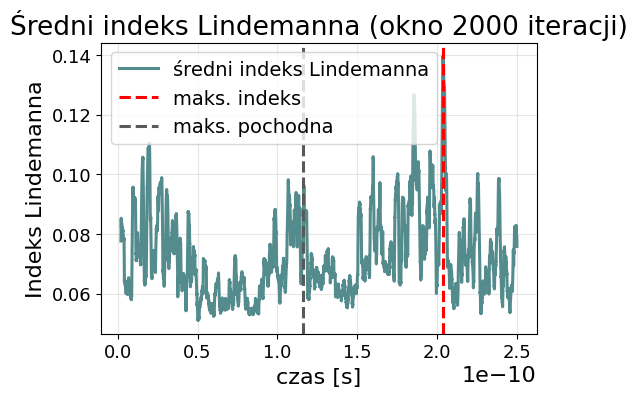

In [22]:
new_figure()
plt.plot(
    time_elapsed,
    mean_delta,
    color=COLOR_SERIES,
    label="średni indeks Lindemanna",
)
plt.axvline(
    time_max_delta,
    color="red",
    linestyle="--",
    linewidth=LINEWIDTH,
    label="maks. indeks",
)
plt.axvline(
    time_max_derivative,
    color="0.35",
    linestyle="--",
    linewidth=LINEWIDTH,
    label="maks. pochodna",
)
finish_plot(
    "czas [s]",
    "Indeks Lindemanna",
    f"Średni indeks Lindemanna (okno {window} iteracji)",
)

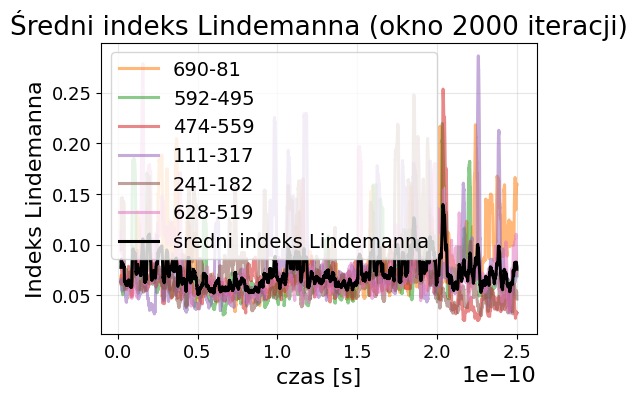

In [23]:
new_figure(multi_series=True)
for column in delta.columns:
    plt.plot(time_elapsed, delta[column], alpha=0.55, label=column)
plt.plot(
    time_elapsed,
    mean_delta,
    color="black",
    linewidth=LINEWIDTH,
    label="średni indeks Lindemanna",
)
finish_plot(
    "czas [s]",
    "Indeks Lindemanna",
    f"Średni indeks Lindemanna (okno {window} iteracji)",
)

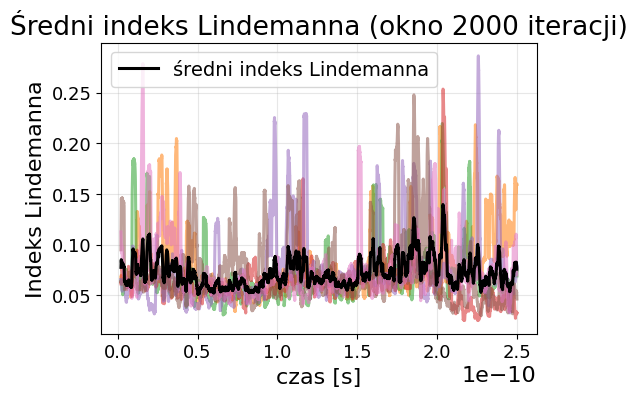

In [24]:
new_figure(multi_series=True)
for column in delta.columns:
    plt.plot(time_elapsed, delta[column], alpha=0.55)
plt.plot(
    time_elapsed,
    mean_delta,
    color="black",
    linewidth=LINEWIDTH,
    label="średni indeks Lindemanna",
)
finish_plot(
    "czas [s]",
    "Indeks Lindemanna",
    f"Średni indeks Lindemanna (okno {window} iteracji)",
)

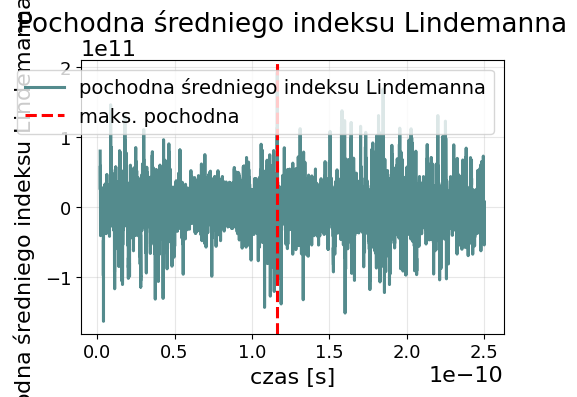

In [25]:
new_figure()
plt.plot(
    time_elapsed,
    mean_delta_derivative,
    color=COLOR_SERIES,
    label="pochodna średniego indeksu Lindemanna",
)
plt.axvline(
    time_max_derivative,
    color="red",
    linestyle="--",
    linewidth=LINEWIDTH,
    label="maks. pochodna",
)
finish_plot(
    "czas [s]",
    r"Pochodna średniego indeksu Lindemanna [s$^{-1}$]",
    "Pochodna średniego indeksu Lindemanna",
)